# 1. Тренировка агрегации меток асессоров

Грамотно формализовать и агрегировать метки асессоров - попловина успеха измерения качества в любой задаче. В текущем примере мы попробуем сравнить два популярных метода агрегации оценок асессоров, которые ранее были выставлены в соотвествии с какой-то инструкцией.

Итак, необходимо считать данные, агрегировать метки асессоров при попощи наивного и продвинутого алгоритмов, а затем устроить "стресс-тестирование" этим методам агрегации. Удачи!

Подробнеее:

https://github.com/ahndana/nlp-final-snli (https://nlp.stanford.edu/projects/snli/)

https://habr.com/ru/companies/mts_ai/articles/747024/

In [2]:
# !pip install crowd-kit

In [3]:
import pandas as pd
from crowdkit.aggregation import MajorityVote, DawidSkene

In [4]:
df = pd.read_csv('snli_1.0_dev.txt', sep = '\t')
df = df.dropna()
df = df[df.gold_label != "-"]
labels = df[df.columns[-5:].to_list()]
labels = labels.reset_index()
df = df[["sentence1", "sentence2", "gold_label"]]
df.reset_index(drop=True, inplace=True)
melted_labels = labels.melt(id_vars="index", )
melted_labels.columns = ["task", "worker", "label"]

In [5]:
df

,sentence1,sentence2,gold_label
0,Two women are embracing while holding to go pa...,The sisters are hugging goodbye while holding ...,neutral
1,Two women are embracing while holding to go pa...,Two woman are holding packages.,entailment
2,Two women are embracing while holding to go pa...,The men are fighting outside a deli.,contradiction
3,"Two young children in blue jerseys, one with t...",Two kids in numbered jerseys wash their hands.,entailment
4,"Two young children in blue jerseys, one with t...",Two kids at a ballgame wash their hands.,neutral
...,...,...,...
9826,A small girl wearing a pink jacket is riding o...,The carousel is moving.,entailment
9827,A small girl wearing a pink jacket is riding o...,The girl is moving at the speed of light.,contradiction
9828,A young girl with blue and pink ribbons in her...,People in a water fountain,entailment
9829,A young girl with blue and pink ribbons in her...,A young girl knits a sweater,contradiction


In [6]:
melted_labels.head()

,task,worker,label
0,0,label1,neutral
1,1,label1,entailment
2,2,label1,contradiction
3,3,label1,entailment
4,4,label1,neutral


## На исходных данных

### умный метод - девид скин

In [7]:
model = DawidSkene(n_iter=100)
agg = model.fit_predict_proba(melted_labels)
model.errors_

contradiction  entailment   neutral
worker label                                             
label1 neutral             0.022245    0.073193  0.916056
       entailment          0.006339    0.924327  0.054742
       contradiction       0.971416    0.002480  0.029203
label2 entailment          0.035447    0.863975  0.109103
       contradiction       0.878861    0.020176  0.066653
       neutral             0.085692    0.115850  0.824243
label3 neutral             0.081418    0.112214  0.815263
       entailment          0.028050    0.862576  0.114079
       contradiction       0.890531    0.025210  0.070658
label4 neutral             0.074406    0.097449  0.822511
       entailment          0.024279    0.882665  0.112031
       contradiction       0.901315    0.019886  0.065458
label5 neutral             0.081728    0.096688  0.829199
       entailment          0.024291    0.890406  0.100554
       contradiction       0.893981    0.012906  0.070247

<Axes: >

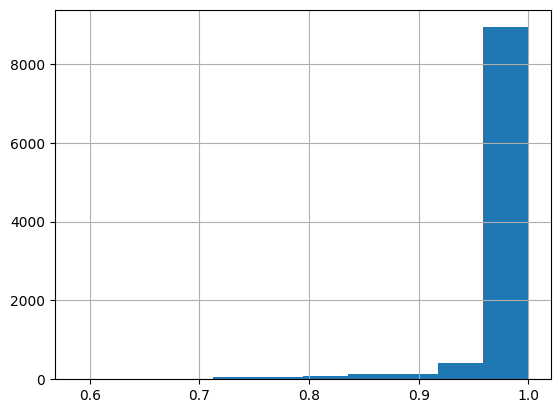

In [8]:
agg_labels = pd.DataFrame([agg.idxmax(axis=1), agg.max(axis=1)]).T.reset_index(drop=True)
df = pd.concat([df, agg_labels], axis=1, ignore_index=True)
df.columns = ["sent1", "sent2", "gold_label", "agg_label", "proba"]
df.proba.hist()

In [9]:
agg_labels.to_csv('agg_labels_devid_5.csv')

### метод "моды"

In [10]:
selected_melted_labels = melted_labels[melted_labels.worker.isin(["label1", "label4", "label5"])]
another_model = DawidSkene()
agg_ds = another_model.fit_predict_proba(selected_melted_labels)

mv_model = MajorityVote()
agg_mv = mv_model.fit_predict_proba(selected_melted_labels)

agg_labels_ds = pd.DataFrame([agg_ds.idxmax(axis=1), agg_ds.max(axis=1)]).T.reset_index(drop=True)
agg_labels_mv = pd.DataFrame([agg_mv.idxmax(axis=1), agg_mv.max(axis=1)]).T.reset_index(drop=True)

df = pd.concat([df, agg_labels_ds, agg_labels_mv], axis=1, ignore_index=True)
df.columns = ["sent1", "sent2", "gold_label", "agg_label_5", "proba_5", "agg_label_3_ds", "proba_3_ds", "agg_label_3_mv", "proba_3_mv"]

diff_ds = df[df.gold_label != df.agg_label_3_ds]
diff_mv = df[df.gold_label != df.agg_label_3_mv]
len(diff_ds), len(diff_mv)

(341, 354)

In [11]:
# на всех экспертах применим метод "моды"
mv_model = MajorityVote()
agg_mv = mv_model.fit_predict_proba(melted_labels)
agg_labels_mv = pd.DataFrame([agg_mv.idxmax(axis=1), agg_mv.max(axis=1)]).T.reset_index(drop=True)
agg_labels_mv.to_csv('agg_labels_moda_5.csv')

In [12]:
melted_labels

,task,worker,label
0,0,label1,neutral
1,1,label1,entailment
2,2,label1,contradiction
3,3,label1,entailment
4,4,label1,neutral
...,...,...,...
49150,9994,label5,entailment
49151,9996,label5,contradiction
49152,9997,label5,entailment
49153,9998,label5,neutral


## Модифицируем данные - добавляем еще асессоров - рандомайзеров

In [13]:
df = pd.read_csv('snli_1.0_dev.txt', sep = '\t')
df = df.dropna()
df = df[df.gold_label != "-"]
labels = df[df.columns[-5:].to_list()]
labels = labels.reset_index()
df = df[["sentence1", "sentence2", "gold_label"]]
df.reset_index(drop=True, inplace=True)
melted_labels = labels.melt(id_vars="index", )
melted_labels.columns = ["task", "worker", "label"]

In [14]:
import numpy as np
import random

COUNT_NEW_WORKERS = 10
new_workers = []
for i in range(COUNT_NEW_WORKERS):
    random.seed(42+i)
    new_labels = np.random.choice(melted_labels['label'].unique(), size = melted_labels['task'].nunique() )
    melted_labels_add = pd.DataFrame({'label':new_labels, 'task': melted_labels['task'].unique()})
    melted_labels_add['worker'] = f'label{i+6}'
    new_workers.append(melted_labels_add)
melted_labels = pd.concat([melted_labels]+new_workers)

In [15]:
melted_labels

,task,worker,label
0,0,label1,neutral
1,1,label1,entailment
2,2,label1,contradiction
3,3,label1,entailment
4,4,label1,neutral
...,...,...,...
9826,9994,label15,contradiction
9827,9996,label15,neutral
9828,9997,label15,entailment
9829,9998,label15,entailment


### умный метод

In [16]:
model = DawidSkene(n_iter=100)
agg = model.fit_predict_proba(melted_labels)
model.errors_

contradiction  entailment   neutral
worker  label                                             
label1  neutral             0.022516    0.073692  0.916389
        entailment          0.006333    0.923771  0.054612
        contradiction       0.971151    0.002537  0.028999
label2  entailment          0.035401    0.863731  0.108798
        contradiction       0.878631    0.020177  0.066548
        neutral             0.085968    0.116092  0.824653
label3  neutral             0.081602    0.112431  0.815786
        entailment          0.028019    0.862349  0.113753
        contradiction       0.890378    0.025220  0.070461
label4  neutral             0.074607    0.097672  0.823037
        entailment          0.024242    0.882428  0.111704
        contradiction       0.901151    0.019900  0.065259
label5  neutral             0.081936    0.097029  0.829601
        entailment          0.024238    0.890065  0.100330
        contradiction       0.893826    0.012907  0.070069
label6  contradiction       0.346124    0.320961  0.332154
        entailment          0.323856    0.351240  0.339079
        neutral             0.330020    0.327799  0.328767
label7  entailment          0.338481    0.328372  0.333217
        neutral             0.320399    0.333548  0.340450
        contradiction       0.341120    0.338081  0.326333
label8  contradiction       0.334383    0.321094  0.319417
        neutral             0.330221    0.347455  0.333370
        entailment          0.335395    0.331451  0.347213
label9  neutral             0.326972    0.327020  0.323971
        entailment          0.335565    0.335845  0.340282
        contradiction       0.337463    0.337135  0.335747
label10 neutral             0.327266    0.333376  0.335145
        entailment          0.343534    0.343810  0.332866
        contradiction       0.329199    0.322814  0.331989
label11 entailment          0.341491    0.338263  0.340422
        neutral             0.332322    0.332255  0.331438
        contradiction       0.326187    0.329482  0.328140
label12 contradiction       0.326117    0.335251  0.334684
        entailment          0.330793    0.331900  0.330256
        neutral             0.343090    0.332849  0.335059
label13 entailment          0.331079    0.317309  0.325498
        contradiction       0.344204    0.343546  0.337443
        neutral             0.324717    0.339145  0.337058
label14 neutral             0.332007    0.317325  0.324529
        entailment          0.326236    0.343675  0.324861
        contradiction       0.341757    0.339000  0.350610
label15 neutral             0.340937    0.348192  0.325667
        contradiction       0.335095    0.330161  0.331397
        entailment          0.323968    0.321648  0.342936

<Axes: >

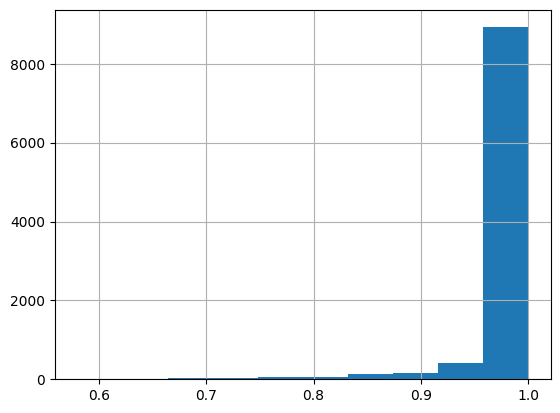

In [17]:
agg_labels = pd.DataFrame([agg.idxmax(axis=1), agg.max(axis=1)]).T.reset_index(drop=True)
df = pd.concat([df, agg_labels], axis=1, ignore_index=True)
df.columns = ["sent1", "sent2", "gold_label", "agg_label", "proba"]
df.proba.hist()

In [18]:
agg_labels.to_csv('agg_labels_devid_15.csv')

### метод "моды"

In [19]:
# на всех экспертах применим метод "моды"
mv_model = MajorityVote()
agg_mv = mv_model.fit_predict_proba(melted_labels)
agg_labels_mv = pd.DataFrame([agg_mv.idxmax(axis=1), agg_mv.max(axis=1)]).T.reset_index(drop=True)
agg_labels_mv.to_csv('agg_labels_moda_15.csv')

In [ ]:
BASE_WORKERS = 5  # исходные

for NUM_BAD_LABELERS in [1, 5, 10, 100]:
    print("Генерируем файлы для", BASE_WORKERS + NUM_BAD_LABELERS, "асессоров")

    # настоящие ассесоры
    df = pd.read_csv('snli_1.0_dev.txt', sep='\t')
    df = df.dropna()
    df = df[df.gold_label != "-"]
    labels = df[df.columns[-BASE_WORKERS:].to_list()].reset_index()
    df = df[["sentence1", "sentence2", "gold_label"]]
    df.reset_index(drop=True, inplace=True)

    melted_labels = labels.melt(id_vars="index")
    melted_labels.columns = ["task", "worker", "label"]

    # добавляем NUM_BAD_LABELERS рандомных асессоров
    new_workers = []
    for i in range(NUM_BAD_LABELERS):
        random.seed(42 + i)
        new_labels = np.random.choice(
            melted_labels["label"].unique(),
            size=melted_labels["task"].nunique()
        )
        melted_labels_add = pd.DataFrame(
            {"label": new_labels, "task": melted_labels["task"].unique()}
        )
        melted_labels_add["worker"] = f"label{BASE_WORKERS + i + 1}"
        new_workers.append(melted_labels_add)

    melted_labels_ext = pd.concat([melted_labels] + new_workers)

    # Dawid–Skene
    model = DawidSkene(n_iter=100)
    agg = model.fit_predict_proba(melted_labels_ext)
    agg_labels = pd.DataFrame(
        [agg.idxmax(axis=1), agg.max(axis=1)]
    ).T.reset_index(drop=True)
    agg_labels.to_csv(f"agg_labels_devid_{BASE_WORKERS + NUM_BAD_LABELERS}.csv")

    # Majority vote
    mv_model = MajorityVote()
    agg_mv = mv_model.fit_predict_proba(melted_labels_ext)
    agg_labels_mv = pd.DataFrame(
        [agg_mv.idxmax(axis=1), agg_mv.max(axis=1)]
    ).T.reset_index(drop=True)
    agg_labels_mv.to_csv(f"agg_labels_moda_{BASE_WORKERS + NUM_BAD_LABELERS}.csv")

Генерируем файлы для 6 асессоров
Генерируем файлы для 10 асессоров
Генерируем файлы для 15 асессоров
Генерируем файлы для 105 асессоров


## Анализ отличий

In [26]:
agg_labels_mv = dict()
agg_labels_devid = dict()
agg_labels_devid = pd.read_csv(f'agg_labels_devid_5.csv', index_col = 0)
agg_labels_devid.columns = ['label_devid', 'p_label']
agg_labels_mv = pd.read_csv(f'agg_labels_moda_5.csv', index_col = 0)
agg_labels_mv.columns = ['label_moda', 'p_label']

for NUM_BAD_LABELERS in [1, 5, 10, 100]:
    print("NUM_BAD =", NUM_BAD_LABELERS)
    agg_labels_devid_bad = pd.read_csv(f'agg_labels_devid_{5 + NUM_BAD_LABELERS}.csv', index_col = 0)
    agg_labels_devid_bad.columns = ['label_devid_bad', 'p_label']
    agg_labels_mv_bad = pd.read_csv(f'agg_labels_moda_{5 + NUM_BAD_LABELERS}.csv', index_col = 0)
    agg_labels_mv_bad.columns = ['label_moda_bad', 'p_label']
    
    print("Devid Skeene:")
    devid = pd.concat([agg_labels_devid, agg_labels_devid_bad], axis = 1)
    print(devid.apply(lambda x: x['label_devid']!=x['label_devid_bad'], axis=1).mean())


    print("Majority:")
    major = pd.concat([agg_labels_mv, agg_labels_mv_bad], axis = 1)
    print(major.apply(lambda x: x['label_moda']!=x['label_moda_bad'], axis=1).mean())
    print()

NUM_BAD = 1
Devid Skeene:
0.0
Majority:
0.020343810395687112

NUM_BAD = 5
Devid Skeene:
0.0
Majority:
0.07252568406062455

NUM_BAD = 10
Devid Skeene:
0.0
Majority:
0.1430169870816804

NUM_BAD = 100
Devid Skeene:
0.00020343810395687112
Majority:
0.4582443291628522



## Итоги 1 части:

|x|Девид Скин|Голосование|
|---|---|---|
| % разлинчых итоговых меток для 1 "паршивой овцы" | 0%| 2%|
| % разлинчых итоговых меток для 5 "паршивых овец" | 0%| 7%|
| % разлинчых итоговых меток для 10 "паршивых овец"|0%| 14%|

На практике, среди размечтиков каждый может ошибиться и разница в "порядочности" при выполнении работы не так заметна, как в текущем примере. Однако данный пример позволяет нагялдно визуализировать важность использования продвинутых алгоритмов, не смотря на простоту освоения "наивных" методов.

# 2. Составить ml-system-design-doc

Берем свой процесс ИЛИ с сайта https://www.evidentlyai.com/ml-system-design любой процесс с тегом NLP

Заполняем https://github.com/IrinaGoloshchapova/ml_system_design_doc_ru?tab=readme-ov-file 

На основе этого определяем гиперпараметры своего ML-решения


# Критерии оценки

1 часть - получены корректные количественные результаты

2 часть - полнота и релевантность описанного документа:
- Полнота: проверяем все ли аспекты решения запланированы к проверке? Все ли необходимые для дальнейшего анализа вводные описаны?
- Релевантность: нет ли лишних проверок? Нет ли лишней или запутывающей информации?
